# TitanMAG × DAPT 2020 — APT Phase Detection


## 0. Imports & Seed

In [1]:
import os, glob, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything(SEED)

DEVICE = torch.device('cpu')
print('Device:', DEVICE)

Device: cpu


## 1. Cấu hình

In [2]:
SYNTHETIC_DATA = False
DAPT_BASE = '/kaggle/input/datasets/sowmyamyneni/dapt2020/csv'
DAPT_CSV_PATHS = {
    1: [f'{DAPT_BASE}/enp0s3-monday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-monday-pvt.pcap_Flow.csv'],
    2: [f'{DAPT_BASE}/enp0s3-public-tuesday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-tuesday.pcap_Flow.csv'],
    3: [f'{DAPT_BASE}/enp0s3-public-wednesday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-wednesday.pcap_Flow.csv'],
    4: [f'{DAPT_BASE}/enp0s3-public-thursday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-thursday.pcap_Flow.csv'],
    5: [f'{DAPT_BASE}/enp0s3-tcpdump-friday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-tcpdump-pvt-friday.pcap_Flow.csv'],
}
DAPT_LABEL_COL = 'Label'

ATTACK_TO_PHASE = {

    'Benign': 0, 'benign': 0, 'BENIGN': 0, 'Normal': 0, 'normal': 0,

    'Network Scan': 1, 'NetworkScan': 1, 'network scan': 1,
    'Web vulnerability Scan': 1, 'Web Vulnerability Scan': 1,
    'WebVulnerabilityScan': 1, 'Port Scan': 1, 'PortScan': 1,
    'Reconnaissance': 1,

    'SQL injection': 2, 'SQL Injection': 2, 'SQLInjection': 2,
    'Backdoor': 2, 'backdoor': 2,
    'Malware Download': 2, 'MalwareDownload': 2,
    'Command Injection': 2, 'CommandInjection': 2,
    'CSRF': 2, 'csrf': 2,
    'Account brute force': 2, 'AccountBruteForce': 2, 'BruteForce': 2,
    'Foothold': 2,
 
    'DoS': 3, 'dos': 3, 'DenialOfService': 3,
    'Privilege escalation': 3, 'PrivilegeEscalation': 3,
    'Lateral Movement': 3, 'LateralMovement': 3,

    'Data Exfiltration': 4, 'DataExfiltration': 4,
    'Exfiltration': 4, 'exfiltration': 4,
}
APT_PHASE_NAMES = [
    'Benign', 'Reconnaissance', 'Foothold', 'Lateral Movement', 'Exfiltration'
]
N_APT_PHASES = len(APT_PHASE_NAMES)


N_PCA       = 20
N_BINS      = 32
BATCH_SIZE  = 1024
NUM_WORKERS = 4
EPOCHS      = 7
LR          = 1e-3
D_MODEL     = 256
N_HEADS     = 8
N_PERSIST   = 4
SWA_WINDOW  = 16
LMM_LAYERS  = 6          
LMM_DROPOUT = 0.1        
HEAD_DROPOUT = 0.1       
OUTLIER_TH  = 3.0
PRE_BATCH   = 50_000

N_SYNTHETIC = 5000
N_FEATURES  = 40

if not SYNTHETIC_DATA:
    for day, paths in DAPT_CSV_PATHS.items():
        for path in paths:
            status = '' if os.path.exists(path) else ''
            print(f'  Day {day}: {os.path.basename(path)} {status}')

  Day 1: enp0s3-monday.pcap_Flow.csv 
  Day 1: enp0s3-monday-pvt.pcap_Flow.csv 
  Day 2: enp0s3-public-tuesday.pcap_Flow.csv 
  Day 2: enp0s3-pvt-tuesday.pcap_Flow.csv 
  Day 3: enp0s3-public-wednesday.pcap_Flow.csv 
  Day 3: enp0s3-pvt-wednesday.pcap_Flow.csv 
  Day 4: enp0s3-public-thursday.pcap_Flow.csv 
  Day 4: enp0s3-pvt-thursday.pcap_Flow.csv 
  Day 5: enp0s3-tcpdump-friday.pcap_Flow.csv 
  Day 5: enp0s3-tcpdump-pvt-friday.pcap_Flow.csv 


## 2. Load dữ liệu DAPT 2020

In [3]:
def generate_synthetic_dapt(n_per_phase=1000, n_features=40, seed=42):
    np.random.seed(seed)
    dfs = []
    configs = [
        (0.3, 0.1, []),
        (0.5, 0.3, [0, 1, 2]),
        (0.6, 0.4, [5, 6, 7]),
        (0.7, 0.3, [10, 11]),
        (0.9, 0.5, [15, 16]),
    ]
    for phase_id, (mu, sigma, skew) in enumerate(configs):
        data = np.abs(np.random.randn(n_per_phase, n_features) * sigma + mu)
        for f in skew:
            data[:, f] += np.random.exponential(2.0, n_per_phase)
        df_p = pd.DataFrame(data, columns=[f'f{i}' for i in range(n_features)])
        df_p['APT_Phase'] = phase_id
        dfs.append(df_p)
    return pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)


def load_real_dapt(csv_paths, attack_to_phase, label_col_hint='Stage'):

    all_files = []
    for day, paths in csv_paths.items():
        if not isinstance(paths, list):
            paths = [paths]
        for path in paths:
            if os.path.exists(path):
                all_files.append((day, path))
            else:
                print(f'  [Day {day}]  Không tìm thấy, bỏ qua: {path}')

    if not all_files:
        raise FileNotFoundError(f'Không tìm thấy bất kỳ file CSV nào tại: {DAPT_BASE}')

    standard_cols = None
    for day, path in all_files:
        with open(path, 'r', errors='ignore') as f:
            first_line = f.readline()
    
        has_header = any(h in first_line.lower() for h in ["flow id", "flow_id", "src ip", "src_ip", "protocol", "timestamp"])
        if has_header:
            df_temp = pd.read_csv(path, nrows=5)
            standard_cols = list(df_temp.columns)
     
            break

    if standard_cols is None:
        raise ValueError("Không tìm thấy file nào có header để lấy danh sách cột chuẩn!")

    dfs = []
    for day, path in all_files:
        with open(path, 'r', errors='ignore') as f:
            first_line = f.readline()
        has_header = any(h in first_line.lower() for h in ["flow id", "flow_id", "src ip", "src_ip", "protocol", "timestamp"])

     
        try:
            if has_header:
                df_d = pd.read_csv(path, low_memory=False)
            
                df_d = df_d.reindex(columns=standard_cols)
            else:
               
                df_d = pd.read_csv(path, header=None, names=standard_cols, low_memory=False)
            
            df_d['Day'] = day
            dfs.append(df_d)
        except Exception as e:
            print(f'   Lỗi khi đọc file {os.path.basename(path)}: {e}')

    if not dfs:
        raise ValueError("Không load được dataframe nào.")

    df = pd.concat(dfs, ignore_index=True)


    label_col = None
    search_cols = []
    if label_col_hint:
        search_cols.append(label_col_hint)
    search_cols.extend(['Stage', 'stage', 'Activity', 'activity', 'Label', 'label', 'Attack', 'attack', 'Class', 'Category'])
    
    for c in search_cols:
        if c in df.columns:
            label_col = c
            break

    if label_col is None:
        raise ValueError(f'Không tìm thấy cột nhãn. Cột hiện có: {list(df.columns)}')
    print(f'Cột nhãn được chọn: "{label_col}"')

    for lbl in sorted(df[label_col].dropna().unique()):
        print(f'  "{lbl}": {(df[label_col]==lbl).sum():,}')


    df['APT_Phase'] = df[label_col].astype(str).map(attack_to_phase)
    unmapped = df['APT_Phase'].isna()
    if unmapped.any():
        print(f' {unmapped.sum():,} rows unmapped → fallback theo Day')
        df.loc[unmapped, 'APT_Phase'] = df.loc[unmapped, 'Day'].map({1:0, 2:1, 3:2, 4:3, 5:4})
    df['APT_Phase'] = df['APT_Phase'].fillna(0).astype(int)

    for i, name in enumerate(APT_PHASE_NAMES):
        cnt = (df['APT_Phase']==i).sum()
        print(f'  Phase {i} ({name:<22}): {cnt:>10,} ({cnt/len(df)*100:5.1f}%)')
    
    return df, label_col


if SYNTHETIC_DATA:
    
    df = generate_synthetic_dapt(N_SYNTHETIC // N_APT_PHASES, N_FEATURES)
    feature_cols = [c for c in df.columns if c != 'APT_Phase']
else:
    print('Real DAPT 2020')
    df, _lc = load_real_dapt(DAPT_CSV_PATHS, ATTACK_TO_PHASE, DAPT_LABEL_COL)
    drop = {'APT_Phase', 'Day', _lc, 'Label', 'label', 'Attack', 'attack', 'Class', 'Category'}
    const_cols = set(df.std(numeric_only=True).pipe(lambda s: s[s==0]).index)
    feature_cols = [c for c in df.columns
                    if c not in drop | const_cols
                    and pd.api.types.is_numeric_dtype(df[c])]
    print(f'Feature cols: {len(feature_cols)}')

X_raw = df[feature_cols].values.astype(np.float32)
y_raw = df['APT_Phase'].values.astype(np.int64)


Real DAPT 2020
Cột nhãn được chọn: "Stage"
  "BENIGN": 19,454
  "Benign": 44,258
  "Data Exfiltration": 15
  "Establish Foothold": 8,604
  "Lateral Movement": 2,451
  "Reconnaissance": 11,909
 8,604 rows unmapped → fallback theo Day
  Phase 0 (Benign                ):     63,712 ( 73.5%)
  Phase 1 (Reconnaissance        ):     11,909 ( 13.7%)
  Phase 2 (Foothold              ):      8,592 (  9.9%)
  Phase 3 (Lateral Movement      ):      2,451 (  2.8%)
  Phase 4 (Exfiltration          ):         27 (  0.0%)
Feature cols: 67


## 3. Train / Val / Test Split

In [4]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_raw, y_raw, test_size=0.3, stratify=y_raw, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=2/3, stratify=y_tmp, random_state=SEED)
del X_raw, X_tmp, y_tmp; gc.collect()

0

## 4. Robust Preprocessing → PCA → StandardScaler → KBins Tokenize

In [5]:
def robust_clean(X_tr, X_val, X_te, batch=50_000, th=3.0):
    for arr in [X_tr, X_val, X_te]:
        if hasattr(arr, 'values'): arr = arr.values
    X_tr  = X_tr.astype(np.float32)
    X_val = X_val.astype(np.float32)
    X_te  = X_te.astype(np.float32)

    s = min(100_000, len(X_tr))
    idx = np.random.choice(len(X_tr), s, replace=False)
    med = np.nanmedian(X_tr[idx], axis=0)
    std = np.nanstd(X_tr[idx],    axis=0); std[std==0] = 1.0

    def clean(A):
        out = []
        for i in range(0, len(A), batch):
            B = A[i:i+batch].copy()
            B[np.isinf(B)] = np.nan
            for c in range(B.shape[1]):
                m = med[c]
                bad = np.isnan(B[:,c]) | (np.abs((B[:,c]-m)/std[c]) > th)
                B[bad, c] = m
            out.append(np.clip(B, -1e6, 1e6))
        return np.vstack(out)

    Xtr, Xva, Xte = clean(X_tr), clean(X_val), clean(X_te)
    return Xtr, Xva, Xte


X_tr, X_val, X_te = robust_clean(X_tr, X_val, X_te, PRE_BATCH, OUTLIER_TH)

nc = min(N_PCA, X_tr.shape[1])
pca = PCA(n_components=nc, random_state=SEED)
X_tr  = pca.fit_transform(X_tr)
X_val = pca.transform(X_val)
X_te  = pca.transform(X_te)
print(f'PCA: {nc} components | variance={pca.explained_variance_ratio_.sum()*100:.1f}%')

sc = StandardScaler()
X_tr  = sc.fit_transform(X_tr)
X_val = sc.transform(X_val)
X_te  = sc.transform(X_te)

kbd = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
tok_tr  = kbd.fit_transform(X_tr).astype(np.int64)
tok_val = kbd.transform(X_val).astype(np.int64)
tok_te  = kbd.transform(X_te).astype(np.int64)

vocab = [int(max(tok_tr[:,i].max(), tok_val[:,i].max(), tok_te[:,i].max())) + 2
         for i in range(tok_tr.shape[1])]
SEQ_LEN = tok_tr.shape[1]

PCA: 20 components | variance=99.5%


## 5. Dataset & DataLoader

In [6]:
class TokenDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).long()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

kw = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
train_loader = DataLoader(TokenDS(tok_tr,  y_tr),  BATCH_SIZE, shuffle=True,  drop_last=True,  **kw)
val_loader   = DataLoader(TokenDS(tok_val, y_val), BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(TokenDS(tok_te,  y_te),  BATCH_SIZE, shuffle=False, **kw)

## 6. TitanMAG v3 (RoPE + TPA)

In [7]:
ROPE_BASE = 10000.0  

def build_rope_cache(seq_len, inv_freq, device):
    t = torch.arange(seq_len, device=device).float()
    angles = torch.outer(t, inv_freq.to(device))   # (L, dh//2)
    cos = torch.cat([angles.cos(), angles.cos()], dim=-1)  # (L, dh)
    sin = torch.cat([angles.sin(), angles.sin()], dim=-1)  # (L, dh)
    return cos, sin

def apply_rope(x, cos, sin):
    cos = cos.unsqueeze(0).unsqueeze(2)   # (1, L, 1, dh)
    sin = sin.unsqueeze(0).unsqueeze(2)   # (1, L, 1, dh)
    half = x.shape[-1] // 2
    x1 = x[..., :half]; x2 = x[..., half:]
    x_rot = torch.cat([-x2, x1], dim=-1)
    return x * cos + x_rot * sin

class TPAProjection(nn.Module):
    def __init__(self, d_model, n_heads, d_head, R):
        super().__init__()
        assert R >= 1 and n_heads >= 1 and d_head >= 1
        self.R, self.h, self.dh = R, n_heads, d_head
        self.A = nn.Linear(d_model, R * n_heads, bias=False)
        self.B = nn.Linear(d_model, R * d_head,  bias=False)
        nn.init.xavier_uniform_(self.A.weight)
        nn.init.xavier_uniform_(self.B.weight)

    def forward(self, x):                     
        B, L, _ = x.shape
        a = self.A(x).view(B, L, self.R, self.h)    
        b = self.B(x).view(B, L, self.R, self.dh)  
 
        out = torch.einsum('blrh,blrd->blhd', a, b) / float(self.R)
        return out                            



class FeatureEmbedding(nn.Module):
    def __init__(self, vocab_sizes, d):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(v, d) for v in vocab_sizes])
        self.pos  = nn.Embedding(len(vocab_sizes), d)
        self.norm = nn.LayerNorm(d)

    def forward(self, x):
        B, L = x.shape
        h = torch.stack([self.embs[i](x[:,i]) for i in range(L)], dim=1)
        p = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        return self.norm(h + self.pos(p))


class NeuralLongTermMemory(nn.Module):

    def __init__(self, d, n_heads=4, lmm_r_q=2, lmm_r_k=2, lmm_r_v=2,
                 num_blocks=4, dropout=0.15):
        super().__init__()
        assert d % n_heads == 0
        self.h  = n_heads
        self.dh = d // n_heads

        self.tpa_q = TPAProjection(d, n_heads, self.dh, lmm_r_q)
        self.tpa_k = TPAProjection(d, n_heads, self.dh, lmm_r_k)
        self.tpa_v = TPAProjection(d, n_heads, self.dh, lmm_r_v)

        inv_freq = 1.0 / (ROPE_BASE ** (torch.arange(0, self.dh, 2).float() / self.dh))
        self.register_buffer('inv_freq', inv_freq)


        self.M_norm = nn.LayerNorm(d)

        self.alpha = nn.Linear(d, 1)
        self.eta   = nn.Linear(d, 1)
        self.theta = nn.Linear(d, 1)

        self.out_proj = nn.Linear(d, d)
        self.norm     = nn.LayerNorm(d)

    def _M(self, x):
        return self.M_norm(x)

    def forward(self, h):
        B, L, D = h.shape

        q = self.tpa_q(h)
        k = self.tpa_k(h)
        v = self.tpa_v(h)

        cos, sin = build_rope_cache(L, self.inv_freq, h.device)   
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

        q_flat = q.reshape(B, L, D)
        k_flat = k.reshape(B, L, D)
        v_flat = v.reshape(B, L, D)

        a = torch.sigmoid(self.alpha(h))
        e = torch.sigmoid(self.eta(h))
        t = torch.sigmoid(self.theta(h)) * 0.1

        Mt = torch.zeros(B, D, device=h.device)
        St = torch.zeros(B, D, device=h.device)
        outs = []
        for i in range(L):
            v_hat = self._M(k_flat[:, i]) + Mt
            St    = e[:, i] * St - t[:, i] * 2 * (v_hat - v_flat[:, i])
            Mt    = (1 - a[:, i]) * Mt + St
            outs.append(self.out_proj(self._M(q_flat[:, i]) + Mt))
        return self.norm(torch.stack(outs, dim=1))


class SlidingWindowAttention(nn.Module):
    def __init__(self, d, n_heads, window=16,
                 swa_r_q=2, swa_r_k=2, swa_r_v=2):
        super().__init__()
        assert d % n_heads == 0
        self.h      = n_heads
        self.dh     = d // n_heads
        self.window = window
        self.scale  = self.dh ** -0.5

        self.tpa_q = TPAProjection(d, n_heads, self.dh, swa_r_q)
        self.tpa_k = TPAProjection(d, n_heads, self.dh, swa_r_k)
        self.tpa_v = TPAProjection(d, n_heads, self.dh, swa_r_v)

        inv_freq = 1.0 / (ROPE_BASE ** (torch.arange(0, self.dh, 2).float() / self.dh))
        self.register_buffer('inv_freq', inv_freq)

        self.out_proj = nn.Linear(d, d)
        self.norm     = nn.LayerNorm(d) 

    def forward(self, x):                
        B, L, D = x.shape

     
        h = self.norm(x)

      
        q = self.tpa_q(h)
        k = self.tpa_k(h)
        v = self.tpa_v(h)

      
        cos, sin = build_rope_cache(L, self.inv_freq, x.device)
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

      
        q = q.permute(0, 2, 1, 3)
        k = k.permute(0, 2, 1, 3)
        v = v.permute(0, 2, 1, 3)

      
        idx  = torch.arange(L, device=x.device)
        diff = idx.unsqueeze(0) - idx.unsqueeze(1)
        mask = (diff > 0) | (diff < -(self.window - 1))
        mask = mask.unsqueeze(0).unsqueeze(0)

        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.masked_fill(mask, float('-inf'))
        attn = F.softmax(attn, dim=-1)

        out = attn @ v                                 
        out = out.permute(0, 2, 1, 3).reshape(B, L, D)  
        return x + self.out_proj(out)


class TitanMAG(nn.Module):
    def __init__(self, vocab_sizes, n_classes,
                 d=256, n_heads=8, n_persist=4, swa_window=16,
                 lmm_blocks=4, lmm_dropout=0.15, head_dropout=0.2,
                 r_q=2, r_k=2, r_v=2):
        super().__init__()
        self.embed  = FeatureEmbedding(vocab_sizes, d)
        self.P      = nn.Parameter(torch.randn(1, n_persist, d) * 0.02)

        self.swa = SlidingWindowAttention(d, n_heads, swa_window,
                                          swa_r_q=r_q, swa_r_k=r_k, swa_r_v=r_v)
        self.lmm = NeuralLongTermMemory(d, n_heads,
                                         lmm_r_q=r_q, lmm_r_k=r_k, lmm_r_v=r_v,
                                         num_blocks=lmm_blocks, dropout=lmm_dropout)

   
        self.merge     = nn.Linear(d * 2, d)
        self.gate      = nn.Linear(d, d)
        self.gate_norm = nn.LayerNorm(d)

     
        self.head = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, n_classes)
        )
        self.np = n_persist

    def forward(self, x):
        B  = x.size(0)
        h  = self.embed(x)
        xt = torch.cat([self.P.expand(B, -1, -1), h], dim=1)

        y_swa = self.swa(xt)
        y_lmm = self.lmm(xt)

        out = self.merge(torch.cat([y_swa, y_lmm], dim=-1))
        out = self.gate_norm(out * torch.sigmoid(self.gate(xt)))
        out = out[:, self.np:].mean(dim=1)
        return self.head(out)


TPA_R_Q = 2
TPA_R_K = 2
TPA_R_V = 2

model = TitanMAG(vocab, N_APT_PHASES,
                 d=D_MODEL, n_heads=N_HEADS, n_persist=N_PERSIST,
                 swa_window=SWA_WINDOW,
                 lmm_blocks=LMM_LAYERS, lmm_dropout=LMM_DROPOUT,
                 head_dropout=HEAD_DROPOUT,
                 r_q=TPA_R_Q, r_k=TPA_R_K, r_v=TPA_R_V).to(DEVICE)

total = sum(p.numel() for p in model.parameters())

## 7. Training

In [8]:
def run_eval(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(DEVICE)).argmax(-1).cpu().numpy())
            trues.append(yb.numpy())
    p, t = np.concatenate(preds), np.concatenate(trues)
    return dict(
        acc  = accuracy_score(t, p),
        f1   = f1_score(t, p, average='weighted', zero_division=0),
        prec = precision_score(t, p, average='weighted', zero_division=0),
        rec  = recall_score(t, p, average='weighted', zero_division=0),
        pred = p, true = t
    )


class_counts = np.bincount(y_tr, minlength=N_APT_PHASES)
weights = torch.tensor(len(y_tr) / (N_APT_PHASES * np.maximum(class_counts, 1)),
                       dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = []
for ep in range(1, EPOCHS + 1):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()
    m = run_eval(model, val_loader)
    history.append({'ep': ep, 'loss': np.mean(losses), **{k: m[k] for k in ['acc','f1','prec','rec']}})
    print(f'[Epoch {ep}/{EPOCHS}] loss={np.mean(losses):.4f} | '
          f'acc={m["acc"]:.4f} | f1={m["f1"]:.4f} | prec={m["prec"]:.4f} | rec={m["rec"]:.4f}')


[Epoch 1/7] loss=0.9096 | acc=0.8728 | f1=0.8835 | prec=0.9072 | rec=0.8728
[Epoch 2/7] loss=0.4723 | acc=0.8525 | f1=0.8698 | prec=0.9115 | rec=0.8525
[Epoch 3/7] loss=0.3153 | acc=0.8846 | f1=0.8980 | prec=0.9243 | rec=0.8846
[Epoch 4/7] loss=0.2308 | acc=0.9048 | f1=0.9160 | prec=0.9330 | rec=0.9048
[Epoch 5/7] loss=0.1953 | acc=0.9052 | f1=0.9137 | prec=0.9310 | rec=0.9052
[Epoch 6/7] loss=0.1585 | acc=0.9016 | f1=0.9101 | prec=0.9295 | rec=0.9016
[Epoch 7/7] loss=0.1405 | acc=0.9083 | f1=0.9157 | prec=0.9318 | rec=0.9083


## 8. Đánh giá Test + Confusion Matrix


===== TEST METRICS =====
Accuracy        : 0.9057
F1  (weighted)  : 0.9141
F1  (macro)     : 0.6783
Precision (w)   : 0.9320
Recall    (w)   : 0.9057

                  precision    recall  f1-score   support

          Benign       0.99      0.90      0.94     12743
  Reconnaissance       0.72      0.92      0.81      2382
        Foothold       0.89      0.94      0.92      1719
Lateral Movement       0.56      0.93      0.70       490
    Exfiltration       0.01      0.40      0.03         5

        accuracy                           0.91     17339
       macro avg       0.64      0.82      0.68     17339
    weighted avg       0.93      0.91      0.91     17339



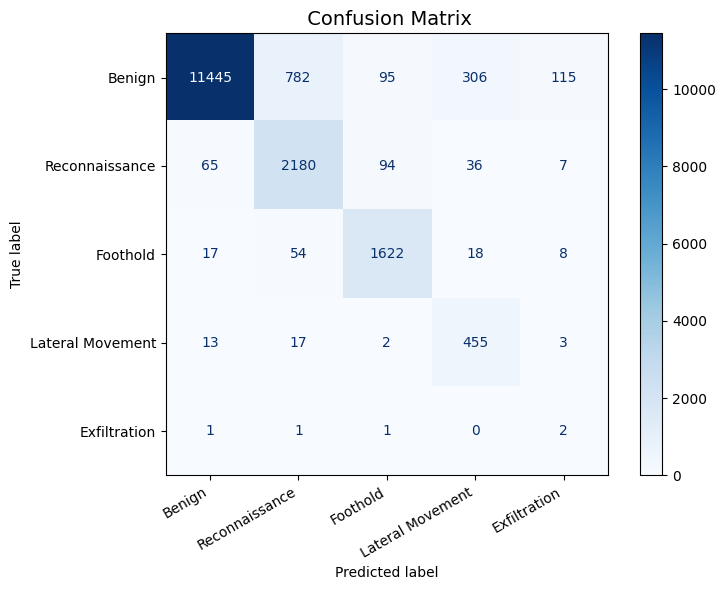

In [9]:
m = run_eval(model, test_loader)
print('\n===== TEST METRICS =====')
print(f'Accuracy        : {m["acc"]:.4f}')
print(f'F1  (weighted)  : {m["f1"]:.4f}')
print(f'F1  (macro)     : {f1_score(m["true"], m["pred"], average="macro", zero_division=0):.4f}')
print(f'Precision (w)   : {m["prec"]:.4f}')
print(f'Recall    (w)   : {m["rec"]:.4f}')
print()
print(classification_report(m['true'], m['pred'],
                             target_names=APT_PHASE_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix(m['true'], m['pred']),
    display_labels=APT_PHASE_NAMES
).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(' Confusion Matrix', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('dapt2020_confusion_matrix.png', dpi=150)
plt.show()